---
title: The Discrete Choice Specific Factors Model
authors:
  - name: Matthew Baker
    affiliations:
      - Department of Economics, Hunter College and The Graduate Center, City University of New York, New York, NY
  - name: Jonathan Conning
    affiliations:
      - Department of Economics, Hunter College and The Graduate Center, City University of New York, New York, NY
downloads:
  - file: pdfs/SFM_Spatial.pdf
    title: Download Academic PDF
exports:
  - format: pdf
    id: sfm-spatial-export
    template: arxiv_nips
---



# The Discrete Choice Specific Factors Model


## A Quantitative Spatial Economics Simulation

This notebook implements a two-region general equilibrium model. It combines two core concepts from modern economics:
1. **Specific Factors Production**: Regions have fixed endowments of capital or land, leading to diminishing returns to labor and downward-sloping labor demand.
2. **Fréchet Distributed Preferences**: Workers have idiosyncratic tastes for locations. This generates a smooth labor supply curve where the parameter $\theta$ (the migration elasticity) determines how easily labor flows in response to wage or amenity gaps.

### 1. The Model Setup

#### Labor Demand (Production)
In each region, firms produce goods using labor ($L$) and a region-specific factor (Capital $K$ in the North, Land $T$ in the South). We use Cobb-Douglas production:

$$F(K, L_N) = K^\alpha L_N^{1-\alpha}$$
$$G(T, L_S) = T^\beta L_S^{1-\beta}$$

The nominal wage $w$ in each region is determined by the Marginal Product of Labor (MPL):
$$w_N = (1-\alpha) \left( \frac{K}{L_N} \right)^\alpha$$

#### Labor Supply (Migration)
Workers choose a location to maximize utility $U_{is} = A_{is} w_{is} \epsilon_{is}$, where $A$ represents amenities and $\epsilon$ is an idiosyncratic shock following a **Fréchet distribution** with shape parameter $\theta$. The share of labor in the North is:

$$\pi_N = \frac{(A_N w_N)^\theta}{(A_N w_N)^\theta + (A_S w_S)^\theta}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import ipywidgets as widgets
from IPython.display import display

def solve_spatial_equilibrium(K, T, A_N, A_S, theta, alpha, beta, total_L=100):
    """
    Solves for the equilibrium labor allocation L_N.
    """
    def excess_labor_supply(L_N):
        L_N = max(1e-6, min(L_N, total_L - 1e-6))
        L_S = total_L - L_N
        
        w_N = (1 - alpha) * (K**alpha) * (L_N**(-alpha))
        w_S = (1 - beta) * (T**beta) * (L_S**(-beta))
        
        actual_ratio = L_N / L_S
        desired_ratio = ((A_N * w_N) / (A_S * w_S))**theta
        
        return actual_ratio - desired_ratio

    L_N_star = brentq(excess_labor_supply, 1e-7, total_L - 1e-7)
    L_S_star = total_L - L_N_star
    w_N_star = (1 - alpha) * (K**alpha) * (L_N_star**(-alpha))
    w_S_star = (1 - beta) * (T**beta) * (L_S_star**(-beta))
    
    return L_N_star, L_S_star, w_N_star, w_S_star

def interactive_plot(K, T, A_N, A_S, theta, alpha, beta):
    total_L = 100
    L_N_eq, L_S_eq, w_N_eq, w_S_eq = solve_spatial_equilibrium(K, T, A_N, A_S, theta, alpha, beta, total_L)
    
    L_range = np.linspace(1, 99, 200)
    W_N = (1 - alpha) * (K**alpha) * (L_range**(-alpha))
    W_S = (1 - beta) * (T**beta) * ((total_L - L_range)**(-beta))
    
    plt.figure(figsize=(12, 7))
    plt.plot(L_range, W_N, label='Labor Demand North', color='#1f77b4', lw=3)
    plt.plot(L_range, W_S, label='Labor Demand South', color='#ff7f0e', lw=3)
    
    plt.scatter([L_N_eq], [w_N_eq], color='#1f77b4', s=100, zorder=5, label=f'Equilibrium N (w_N={w_N_eq:.2f})')
    plt.scatter([L_N_eq], [w_S_eq], color='#ff7f0e', s=100, zorder=5, label=f'Equilibrium S (w_S={w_S_eq:.2f})')
    plt.axvline(L_N_eq, color='black', linestyle='--', alpha=0.3)
    
    plt.title(f'Spatial Equilibrium Simulation (theta={theta})', fontsize=14)
    plt.xlabel('Labor Allocated to North ($L_N$)', fontsize=12)
    plt.ylabel('Nominal Wage ($w$)', fontsize=12)
    plt.legend(frameon=True, loc='upper center')
    plt.grid(True, alpha=0.2)
    plt.ylim(0, max(max(W_N), max(W_S)) * 0.8)
    plt.show()

widgets.interact(interactive_plot, 
    K=widgets.FloatSlider(value=10, min=1, max=100, step=1, description='Capital N'),
    T=widgets.FloatSlider(value=10, min=1, max=100, step=1, description='Land S'),
    A_N=widgets.FloatSlider(value=1.0, min=0.5, max=3.0, step=0.1, description='Amenity N'),
    A_S=widgets.FloatSlider(value=1.0, min=0.5, max=3.0, step=0.1, description='Amenity S'),
    theta=widgets.FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='Theta'),
    alpha=widgets.fixed(0.33),
    beta=widgets.fixed(0.33)
);

interactive(children=(FloatSlider(value=10.0, description='Capital N', min=1.0, step=1.0), FloatSlider(value=1…

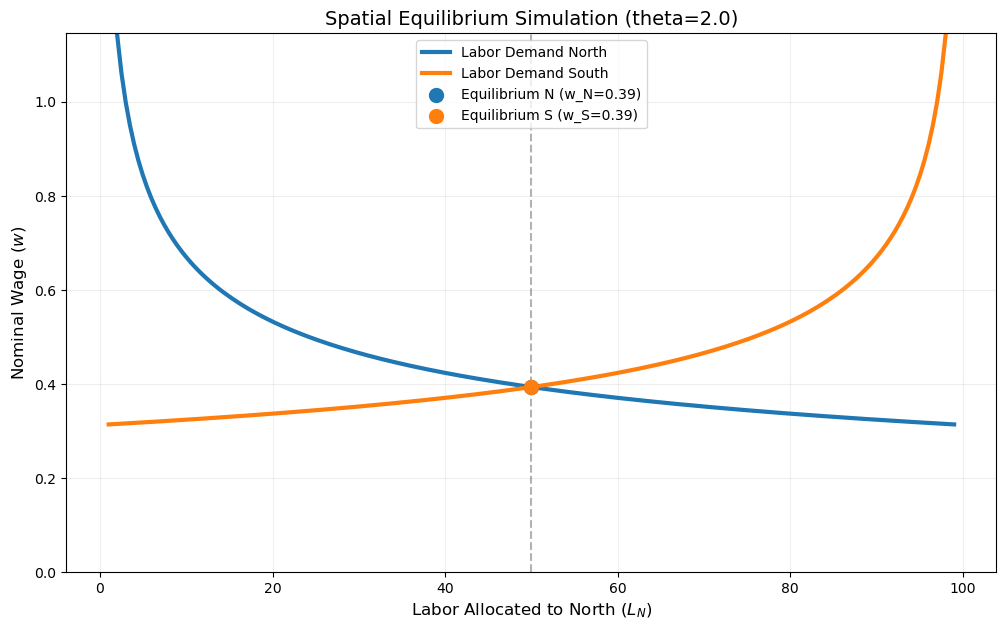

In [2]:
# Static Image Fallback for MyST Website and PDF
interactive_plot(K=10, T=10, A_N=1.0, A_S=1.0, theta=2.0, alpha=0.33, beta=0.33)

### 2. How to Interpret the Results

#### The Importance of $\theta$
* **Low $\theta$ (High Frictions)**: Notice that if you decrease $\theta$, the wage gap between the North and South can be huge even if amenities are equal. This represents a world where people have very strong "home bias" or unique reasons to stay put.
* **High $\theta$ (Fluid Labor)**: If you increase $\theta$, the wages will tend to equalize (after adjusting for amenities). If $\theta = 10$, workers are highly sensitive to even a small wage increase.

#### Amenities vs. Wages
Try increasing **Amenity N**. You will see the equilibrium $L_N$ shift to the right. Interestingly, workers move to the North even as Northern wages *fall*. This shows that in spatial equilibrium, nominal wages do not have to be equal; a high-amenity place can attract workers with lower pay.

#### Productivity Shocks
Increase **Capital N**. This shifts the Northern labor demand curve up. Initially, wages spike in the North, but this induces migration, which eventually puts downward pressure on that wage spike while increasing the total economic output of the region.

### 3. Generalizing to $N$ Locations (Without Geography)

We now expand the model from 2 regions to $N$ regions. Instead of finding a single root, the equilibrium is now defined by a system of equations where the labor in every region $i$ must equal the total labor $\bar{L}$ multiplied by the share of workers who choose region $i$.

$$ \pi_i = \frac{(A_i w_i)^\theta}{\sum_{j=1}^N (A_j w_j)^\theta} $$
$$ L_i = \pi_i \bar{L} $$

We solve this using a fixed-point iteration algorithm, which is highly stable for spatial models.

In [3]:
def solve_n_locations(K_arr, A_arr, theta, alpha, total_L=100, tol=1e-8, max_iter=2000):
    N = len(K_arr)
    # Start with uniform labor
    L = np.ones(N) * (total_L / N)
    
    for _ in range(max_iter):
        L = np.maximum(L, 1e-6) # Prevent division by zero
        
        # Calculate wages
        w = (1 - alpha) * (K_arr**alpha) * (L**-alpha)
        
        # Calculate utility/attractiveness
        u = (A_arr * w)**theta
        
        # Calculate shares
        pi = u / np.sum(u)
        
        # Implied new labor
        L_new = pi * total_L
        
        # Check convergence
        if np.max(np.abs(L_new - L)) < tol:
            return L_new, w
            
        # Update with heavier dampening to ensure stability at high theta
        L = 0.9 * L + 0.1 * L_new
        
    print("Warning: Did not converge")
    return L, w

# Interactive Widget for N=5 Locations
def plot_n_locations(K_1, A_1, theta, alpha):
    N = 5
    # Base parameters for all locations
    K_arr = np.ones(N) * 10
    A_arr = np.ones(N) * 1.0
    
    # Shock location 1
    K_arr[0] = K_1
    A_arr[0] = A_1
    
    L_eq, w_eq = solve_n_locations(K_arr, A_arr, theta, alpha)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    regions = [f'Region {i+1}' for i in range(N)]
    colors = ['#d62728' if i == 0 else '#1f77b4' for i in range(N)]
    
    ax1.bar(regions, L_eq, color=colors, alpha=0.8)
    ax1.set_title('Equilibrium Labor Distribution')
    ax1.set_ylabel('Labor ($L_i$)')
    ax1.set_ylim(0, 100)
    ax1.axhline(100/N, color='k', linestyle='--', alpha=0.5, label='Uniform')
    ax1.legend()
    
    ax2.bar(regions, w_eq, color=colors, alpha=0.8)
    ax2.set_title('Equilibrium Wages')
    ax2.set_ylabel('Nominal Wage ($w_i$)')
    ax2.set_ylim(0, 1.5)
    
    plt.tight_layout()
    plt.show()

widgets.interact(plot_n_locations, 
    K_1=widgets.FloatSlider(value=10, min=1, max=30, step=1, description='Capital Reg 1'),
    A_1=widgets.FloatSlider(value=1.0, min=0.5, max=3.0, step=0.1, description='Amenity Reg 1'),
    theta=widgets.FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='Theta'),
    alpha=widgets.FloatSlider(value=0.33, min=0.05, max=0.95, step=0.05, description='Dim. Returns (alpha)')
);

interactive(children=(FloatSlider(value=10.0, description='Capital Reg 1', max=30.0, min=1.0, step=1.0), Float…

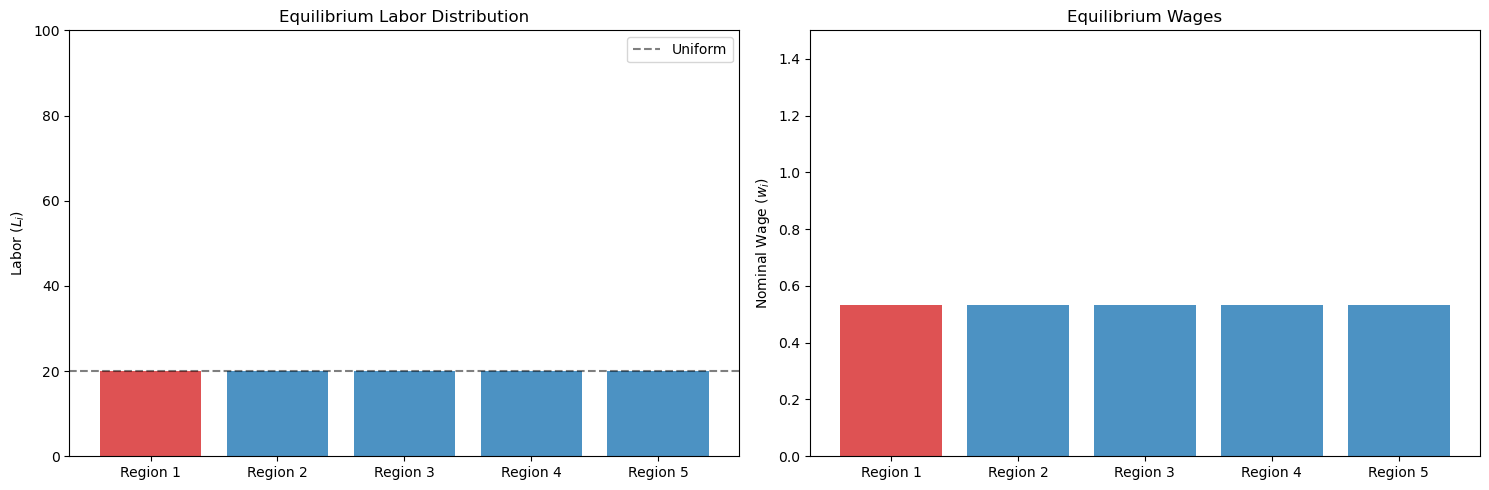

In [4]:
# Static Image Fallback for MyST Website and PDF
plot_n_locations(K_1=10, A_1=1.0, theta=2.0, alpha=0.33)

### 4. Bringing in Geography: The Lattice & Migration Costs

Now we introduce spatial frictions. We assume the $N$ locations are arranged on a 1D grid (a line). The distance between location $i$ and location $j$ is simply $d_{ij} = |i - j|$.

Workers are born with an initial labor endowment in their home region $i$, denoted $L_{0,i}$. Moving from $i$ to $j$ incurs an iceberg migration cost $\mu_{ij} = \exp(\kappa \cdot d_{ij})$, where $\kappa$ governs the severity of the spatial friction.

The Fréchet probability of a worker from origin $i$ moving to destination $j$ is now origin-specific:
$$ \pi_{ij} = \frac{(A_j w_j / \mu_{ij})^\theta}{\sum_{k=1}^N (A_k w_k / \mu_{ik})^\theta} $$

The total labor in destination $j$ is the sum of all migrants from all origins $i$:
$$ L_j = \sum_{i=1}^N \pi_{ij} L_{0,i} $$

In [5]:
def solve_geography(K_arr, A_arr, L0_arr, dist_matrix, kappa, theta, alpha, tol=1e-8, max_iter=2000):
    N = len(K_arr)
    # Migration costs matrix (mu_ij is cost from origin i to destination j)
    mu = np.exp(kappa * dist_matrix)
    
    # Start with labor = initial labor
    L = np.copy(L0_arr)
    
    for _ in range(max_iter):
        L = np.maximum(L, 1e-6)
        
        # Calculate wages
        w = (1 - alpha) * (K_arr**alpha) * (L**-alpha)
        
        # Calculate attractiveness of destination j from origin i
        # Shape: (origins i, destinations j)
        w_j = w.reshape(1, N)
        A_j = A_arr.reshape(1, N)
        
        u_ij = (A_j * w_j / mu)**theta
        
        # Calculate origin-specific shares
        # Sum across destinations (axis=1) for each origin
        u_i_total = np.sum(u_ij, axis=1, keepdims=True)
        pi_ij = u_ij / u_i_total
        
        # Calculate implied new labor at destination j
        # L_j = sum_i (pi_ij * L0_i)
        L_new = np.sum(pi_ij * L0_arr.reshape(N, 1), axis=0)
        
        # Check convergence
        if np.max(np.abs(L_new - L)) < tol:
            return L_new, w, pi_ij
            
        # Heavy dampening for stability at high theta
        L = 0.9 * L + 0.1 * L_new
        
    print("Warning: Did not converge")
    return L, w, None

### 5. Simulating Shock Propagation

Let's put $N=11$ locations on a symmetric 1D lattice, initially endowed with equal labor $L_0 = 10$. 

We will introduce a productivity shock (increasing the Specific Factor $K$) at the center location (Distance = 0). You can use the `kappa` slider to adjust the iceberg migration cost. 

*   When $\kappa = 0$, location doesn't matter (all regions lose equal labor to the booming center).
*   When $\kappa > 0$, you will see the **Population Drain Gradient** (neighboring regions lose more workers than distant ones) and the corresponding **Wage Gradient** (wages rise in the adjacent regions to staunch the bleeding of labor).

In [6]:
def plot_shock_propagation(K_center, kappa, theta, alpha):
    N = 11
    center = N // 2
    
    # 1D Lattice distance matrix
    indices = np.arange(N)
    dist_matrix = np.abs(indices.reshape(N, 1) - indices.reshape(1, N))
    
    # Baseline endowments
    total_L_per_region = 10
    L0_arr = np.ones(N) * total_L_per_region
    
    K_arr = np.ones(N) * 10
    A_arr = np.ones(N) * 1.0
    
    # Apply shock to center
    K_arr[center] = K_center
    
    L_eq, w_eq, pi_ij = solve_geography(K_arr, A_arr, L0_arr, dist_matrix, kappa, theta, alpha)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    x = np.arange(N) - center  # Distance from center
    
    ax1.bar(x, L_eq, color='steelblue', alpha=0.8)
    ax1.set_title(f'Equilibrium Population (kappa={kappa:.2f})')
    ax1.set_xlabel('Distance from Shock')
    ax1.set_ylabel('Labor ($L_j$)')
    ax1.set_ylim(0, 40)
    ax1.axhline(L0_arr[0], color='k', linestyle='--', alpha=0.5, label='Initial / Baseline')
    ax1.legend()
    
    ax2.plot(x, w_eq, marker='o', color='firebrick', linewidth=2, markersize=8)
    ax2.set_title('Equilibrium Wage Gradient')
    ax2.set_xlabel('Distance from Shock')
    ax2.set_ylabel('Nominal Wage ($w_j$)')
    ax2.set_ylim(0.4, 1.2)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

widgets.interact(plot_shock_propagation, 
    K_center=widgets.FloatSlider(value=10, min=10, max=50, step=2, description='Center Capital'),
    kappa=widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.05, description='Friction (kappa)'),
    theta=widgets.FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='Theta'),
    alpha=widgets.FloatSlider(value=0.33, min=0.05, max=0.95, step=0.05, description='Dim. Returns (alpha)')
);

interactive(children=(FloatSlider(value=10.0, description='Center Capital', max=50.0, min=10.0, step=2.0), Flo…

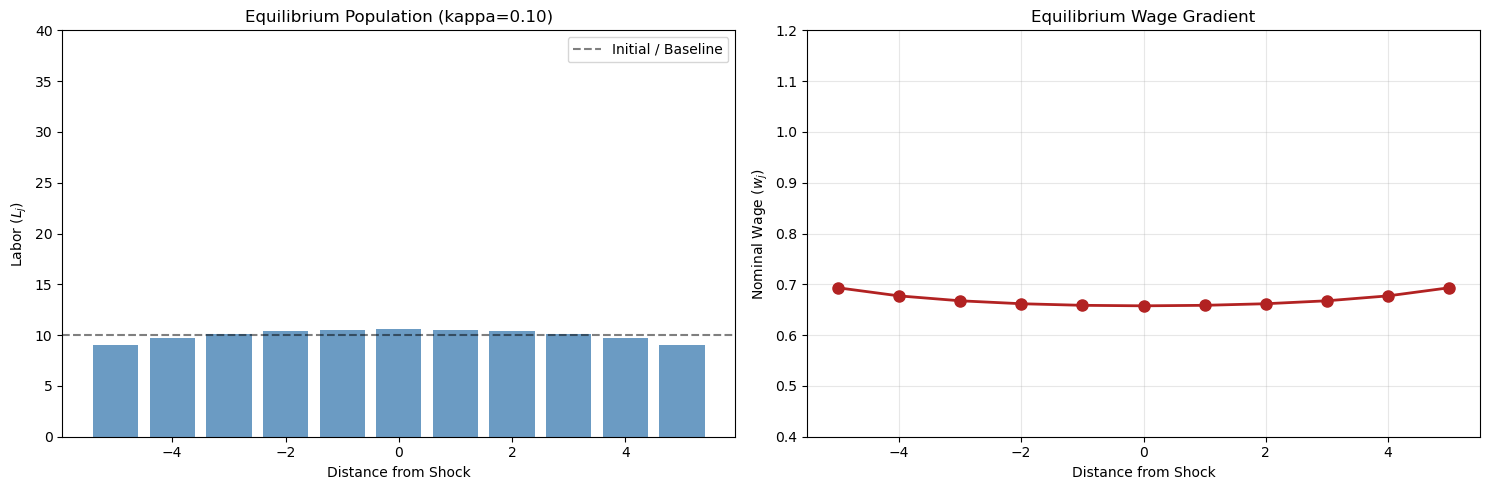

In [7]:
# Static Image Fallback for MyST Website and PDF
plot_shock_propagation(K_center=10, kappa=0.1, theta=2.0, alpha=0.33)

### 6. Synthesis: Solver Mechanics and Spatial Insights

#### 6.1 Behind the Scenes: The Dampened Fixed-Point Solver
To find the equilibrium population distribution across $N$ locations, we use a **fixed-point iteration algorithm**. The algorithm evaluates current wages, calculates the Fréchet utility shares, and proposes a new distribution of labor. 

However, a naive iteration can fail. At high migration elasticities (e.g., $\theta \ge 10$), workers become hypersensitive to tiny wage gaps. If the algorithm immediately shifts all workers to the proposed new locations, they "overreact" and flood a single high-wage region, crashing its wage due to diminishing returns. On the next iteration, they realize their mistake and flood back out, creating a perpetual numerical pendulum that never converges. 

To ensure stable convergence, we implemented a **damper** in the code: `L = 0.9 * L + 0.1 * L_new`. By forcing the algorithm to take small, cautious steps toward the new equilibrium, we completely eliminate numerical ringing and allow the model to reliably find the true spatial equilibrium regardless of the elasticity.

#### 6.2 Economic Interpretation: Centrality Agglomeration vs. Diminishing Returns
When experimenting with the final interactive plot (e.g., setting high friction $\kappa=1.0$ and low labor sensitivity $\theta=0.1$), you'll notice a fascinating spatial dynamic: **wages organically rise at the outer edges of the map and dip in the center.** This is a classic result of economic geography driven by the tension between two core forces:

1.  **The Market Access Effect (In-Migration):** Because our lattice is a finite 1D line segment, regions in the center are geographically "closer to everywhere else." While an edge worker has terrible outside options and is mathematically more likely to stay home, the central regions completely dominate the "in-migration" tug-of-war. The center has twice the geographic catchment area (drawing from neighbors on both sides) compared to the isolated edge. Consequently, the center acts as a natural funnel, swelling with population while the periphery suffers a demographic drain.
2.  **The Specific Factors Effect (Diminishing Returns):** Because the periphery loses workers to the core, the remaining peripheral workers are left with an abundance of fixed capital/land ($K$). This raises their capital-to-labor ratio, making them highly productive at the margin. 

The net result is a beautiful endogenous inequality: **the geographic isolation of the periphery causes an exodus of labor, which in turn spikes the Marginal Product of Labor for those who remain**, organically generating higher wages on the edges of the map to compensate for their lack of market access!

#### 6.3 The Dispersion Force: Controlling Diminishing Returns ($\alpha$)
The entire spatial equilibrium is a tug-of-war between agglomeration forces (like market access) and dispersion forces (what pushes people apart). In our specific factors model, the ultimate dispersion force is governed by the parameter $\alpha$the elasticity of output with respect to the fixed factor (capital). 

In the wage equation $w = (1 - \alpha) K^\alpha L^{-\alpha}$, the exponent $\alpha$ dictates exactly how punishing it is to crowd too many workers into one place:
*   **High $\alpha$ (Strong Dispersion):** The $L^{-\alpha}$ penalty is severe. Even a tiny influx of migrant workers will aggressively crush the local wage. This acts as an iron wall against agglomeration, forcing the population to remain widely dispersed.
*   **Low $\alpha$ (Weak Dispersion):** The wage is barely sensitive to population changes. A booming center can suck in a massive amount of labor from the periphery without its wages crashing, allowing profound agglomeration to run rampant across the map.